pancreas dataset from https://figshare.com/articles/dataset/scIB_pancreas_dataset/25953868

In [1]:
import scanpy as sc
import anndata
import pytorch_lightning as pl  
from scdeepsim.dataset import ScDataModule
from scdeepsim.ae import LightningAE
import os
import numpy as np
import pandas as pd
from scdeepsim.plot import umap_plot, compare_umap
from sklearn.preprocessing import LabelEncoder

/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/tqdm/auto.py:21: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


# Find Batch Effects in AE latent sapce

In [2]:
pancreas = anndata.read_h5ad('../data/scIBPancreas.h5ad')
pancreas.obs

,tech,celltype,size_factors
D101_5,celseq,gamma,0.028492
D101_43,celseq,gamma,0.079348
D101_93,celseq,gamma,0.037932
D102_4,celseq,gamma,0.047685
D172444_23,celseq,gamma,0.038683
...,...,...,...
Sample_1594,smarter,gamma,1.000000
Sample_1595,smarter,gamma,1.000000
Sample_1597,smarter,gamma,1.000000
Sample_1598,smarter,gamma,1.000000


In [3]:
from scdeepsim.transform import NormalLog1pScaler

display(pancreas.obs['tech'].unique())
pancreas_scaler = NormalLog1pScaler()
pancreas.X = pancreas_scaler.fit_transform(pancreas.X)

['celseq', 'celseq2', 'fluidigmc1', 'smartseq2', 'inDrop1', 'inDrop2', 'inDrop3', 'inDrop4', 'smarter']
Categories (9, object): ['celseq', 'celseq2', 'fluidigmc1', 'inDrop1', ..., 'inDrop3', 'inDrop4', 'smarter', 'smartseq2']

In [4]:
pancreasModule = ScDataModule(pancreas, "celltype", "LabelEncoder")
ae = LightningAE(n_genes=pancreas.X.shape[1])

log_dir = "lightning_logs/pancreas/ae"
if not os.path.exists(log_dir):
    os.makedirs(log_dir)

trainer = pl.Trainer(
    max_epochs=50,
    accelerator="auto",
    devices="auto",
    log_every_n_steps=50,
    enable_checkpointing=True,
    logger=True,
    default_root_dir=log_dir
)

ae_path = "checkpoints/pancreas/trained_ae.ckpt"
if os.path.exists(ae_path):
    ae = LightningAE.load_from_checkpoint(ae_path)
else:
    trainer.fit(ae, pancreasModule)
    trainer.save_checkpoint(ae_path)


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [5]:
import torch
from sklearn.preprocessing import StandardScaler

device = next(ae.parameters()).device
X_tensor = torch.tensor(pancreas.X, dtype=torch.float32).to(device)
ae.eval()
with torch.no_grad():
    X_encoded = ae.encode(X_tensor).cpu().numpy()
X_encoded.shape

(16382, 128)

In [6]:
batch_labels = pancreas.obs['tech']
batch_labels.shape

(16382,)

/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


(array([[-11.03297   ,  13.3297    ],
        [-10.865371  ,  13.395873  ],
        [-10.819394  ,  13.404272  ],
        ...,
        [ 15.703993  ,   0.27635813],
        [ 15.714256  ,   0.07606439],
        [ 15.859944  ,   0.39904925]], shape=(16382, 2), dtype=float32),
 <Figure size 700x600 with 1 Axes>)

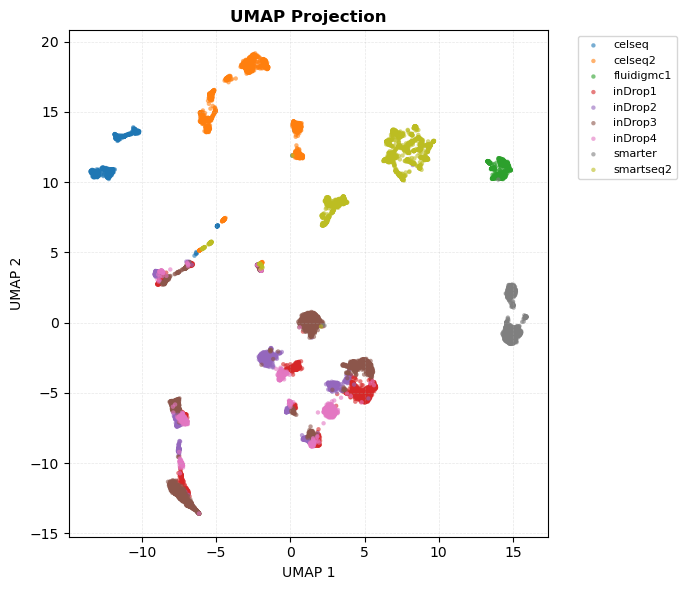

In [9]:
umap_plot(X_encoded, batch_labels)

Batch Effects averaged over cell types

In [7]:
from scdeepsim.control import batch_directions 
cell_types = pancreas.obs['celltype']
batch_effects = batch_directions(X_encoded, batch_labels, cell_types=cell_types)
batch_effects

,celseq,celseq2,fluidigmc1,inDrop1,inDrop2,inDrop3,inDrop4,smarter,smartseq2
0,0.0,-0.768353,-5.092894,-1.109180,-2.357223,-1.460463,-1.937456,0.471786,-0.347178
1,0.0,-0.511896,-3.808590,-0.430479,-0.096033,0.118800,-0.308315,-1.992328,-0.154325
2,0.0,-0.125656,1.710801,1.205488,-0.020084,1.206460,0.128351,-0.550084,-0.601298
3,0.0,-0.909911,-0.312746,1.297573,0.025983,0.586978,1.172827,-0.184655,-1.585427
4,0.0,-0.719781,-2.711668,-3.060656,-3.139222,-3.044126,-2.483045,-1.215485,-0.957141
...,...,...,...,...,...,...,...,...,...
123,0.0,1.545932,0.629789,1.489183,2.002450,0.398463,1.572530,0.153586,1.251789
124,0.0,-1.679550,0.975188,0.913201,0.992033,1.912847,1.801414,2.044603,-0.703059
125,0.0,-0.184018,-3.798811,-0.948640,-0.430336,-1.420769,-0.317266,-2.730118,-2.252473
126,0.0,-1.460949,-0.464263,-0.902423,-0.573738,-0.823167,0.172687,-0.690245,0.027892


Move celseq2 batch effect

/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


(array([[12.451824 , -7.8245277],
        [12.4847765, -7.8590508],
        [12.46879  , -7.8443127],
        ...,
        [-4.5536175,  9.866075 ],
        [-4.264763 ,  9.785131 ],
        [-4.6441865, 10.049854 ]], shape=(16382, 2), dtype=float32),
 <Figure size 700x600 with 1 Axes>)

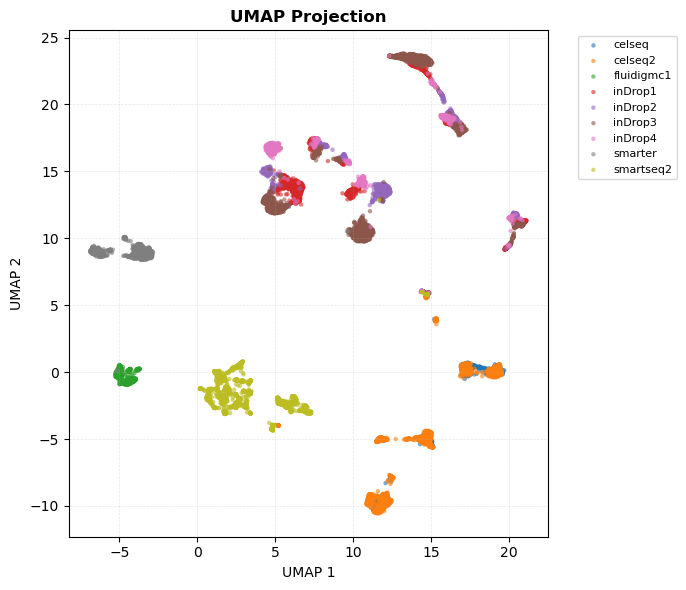

In [11]:
X_intervened = X_encoded.copy()
X_intervened[batch_labels == 'celseq2'] = X_encoded[batch_labels == 'celseq2'] - batch_effects['celseq2'].to_numpy().reshape(1, -1)
umap_plot(X_intervened, batch_labels)

align all batch effects to celseq

/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


(array([[18.031345 ,  7.9542646],
        [17.7317   ,  8.35682  ],
        [17.80357  ,  8.111491 ],
        ...,
        [17.524252 ,  8.531697 ],
        [18.082504 ,  8.220976 ],
        [17.693378 ,  8.026344 ]], shape=(16382, 2), dtype=float32),
 <Figure size 700x600 with 1 Axes>)

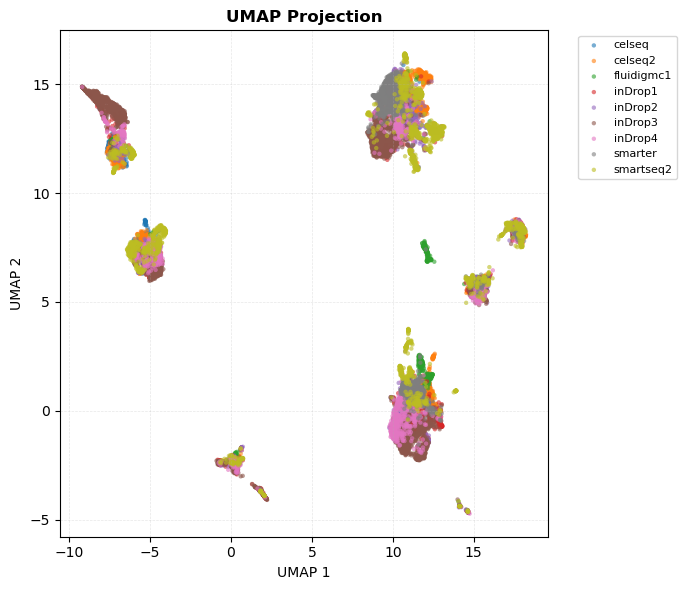

In [12]:
X_batch_moved = X_encoded.copy()
for batch in batch_effects.columns:
    X_batch_moved[batch_labels == batch] = X_encoded[batch_labels == batch] - batch_effects[batch].to_numpy().reshape(1, -1)
umap_plot(X_batch_moved, batch_labels)  

Batch Effects as grand mean shifts. Could be effected by batch-celltype interaction

/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


(array([[-2.183336 , 18.104275 ],
        [-2.1166096, 18.064173 ],
        [-2.2598584, 18.179075 ],
        ...,
        [15.900537 ,  0.8085533],
        [16.024643 ,  1.0467523],
        [15.936119 ,  0.5850538]], shape=(16382, 2), dtype=float32),
 <Figure size 700x600 with 1 Axes>)

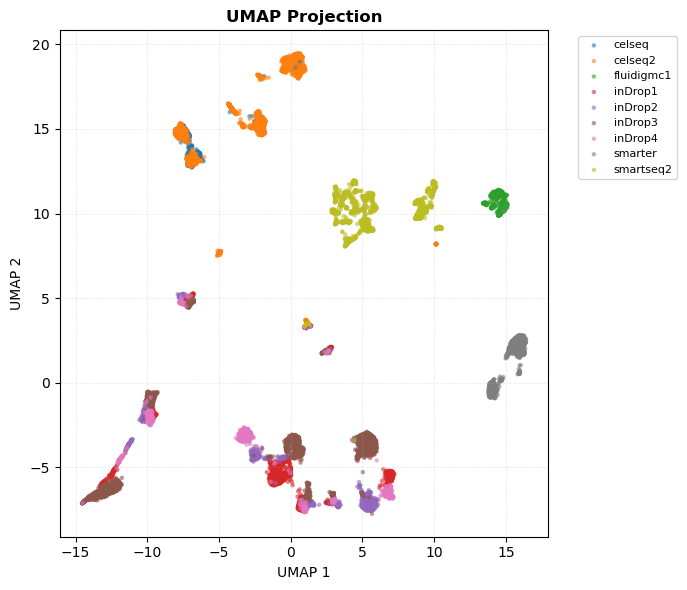

In [13]:
Grand_batch_effects = batch_directions(X_encoded, batch_labels, cell_types=None)
X_grand_batch_moved = X_encoded.copy()
X_grand_batch_moved[batch_labels == 'celseq2'] = X_encoded[batch_labels == 'celseq2'] - Grand_batch_effects['celseq2'].to_numpy().reshape(1, -1)
umap_plot(X_grand_batch_moved, batch_labels)

/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


(array([[-9.223872  ,  0.5125162 ],
        [-9.091759  , -0.11612236],
        [-9.193144  ,  0.20090409],
        ...,
        [-8.787493  , -0.4422444 ],
        [-8.837084  , -0.01891815],
        [-8.906575  , -0.15021822]], shape=(16382, 2), dtype=float32),
 <Figure size 700x600 with 1 Axes>)

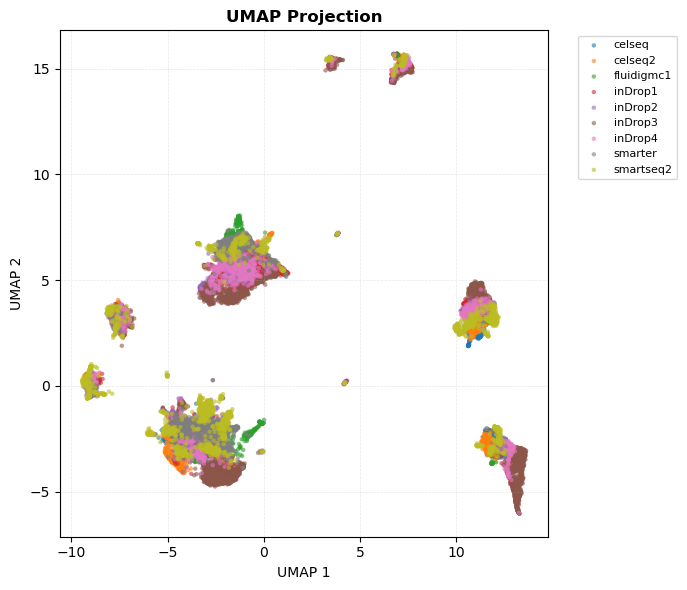

In [14]:
X_grand_batch_moved = X_encoded.copy()
for batch in Grand_batch_effects.columns:
    X_grand_batch_moved[batch_labels == batch] = X_encoded[batch_labels == batch] - Grand_batch_effects[batch].to_numpy().reshape(1, -1)
umap_plot(X_grand_batch_moved, batch_labels)

Performing UMAP on combined dataset (32764 samples, 128 features)...


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP completed. Generating visualizations...


(array([[22.29341  ,  4.0567164],
        [22.467491 ,  3.3774886],
        [22.197212 ,  3.7896926],
        ...,
        [22.338459 ,  3.1457913],
        [22.088737 ,  3.4144921],
        [22.11977  ,  3.5415812]], shape=(16382, 2), dtype=float32),
 array([[22.330307 ,  4.0336056],
        [22.442009 ,  3.3231077],
        [22.178238 ,  3.73348  ],
        ...,
        [22.248241 ,  3.0445607],
        [22.11413  ,  3.406045 ],
        [22.250046 ,  3.4736278]], shape=(16382, 2), dtype=float32),
 <Figure size 1400x600 with 2 Axes>)

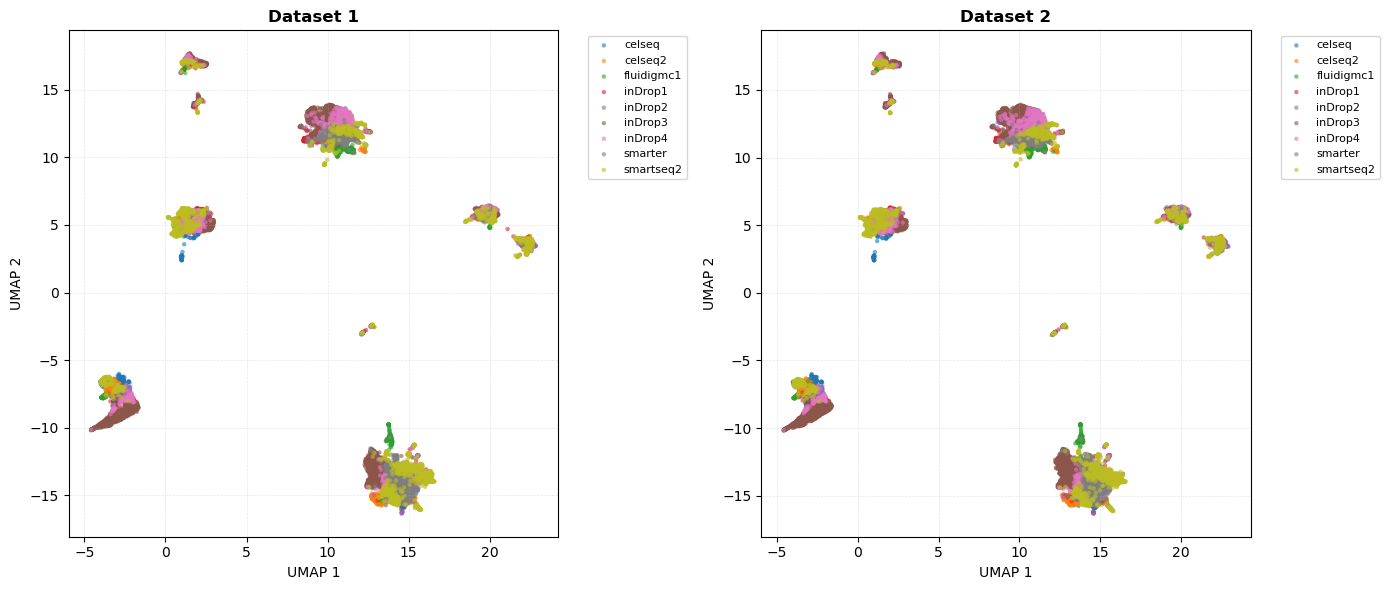

In [ ]:
compare_umap(X_batch_moved, X_grand_batch_moved, labels1=batch_labels, labels2=batch_labels)

# Interpolate in diffusion latent space.

In [8]:
import anndata as ad
import importlib
import scdeepsim.lightning_diffusion as ld

importlib.reload(ld)
from scdeepsim.lightning_diffusion import LightningDiffusion


standard_scaler = StandardScaler()
scaled_X_encoded = standard_scaler.fit_transform(X_encoded)
latent_adata = ad.AnnData(scaled_X_encoded, obs=pancreas.obs.copy())
# use batches as labels
latent_dm = ScDataModule(latent_adata, label_key="tech",
                        encoder="LabelEncoder", batch_size=128, val_split=0.1, balanced_sampling=True)
latent_dm.setup()

dim = scaled_X_encoded.shape[1]
num_classes = int(latent_dm.train_dataset.dataset.classes.max()) + 1    

diffusion = LightningDiffusion(
    input_dim=dim,
    num_classes=num_classes,
    use_ema=True,
    ema_decay=0.999,
)

trainer = pl.Trainer(
    max_epochs=150,
    accelerator="auto",
    devices="auto",
    log_every_n_steps=50,
    enable_checkpointing=True,
    logger=True,
    default_root_dir="lightning_logs/pancreas/diffusion"
)

diffusion_model_path = "checkpoints/pancreas/trained_diffusion_model.ckpt"
if os.path.exists(diffusion_model_path):
    diffusion = LightningDiffusion.load_from_checkpoint(diffusion_model_path)
else:
    trainer.fit(diffusion, latent_dm)   
    trainer.save_checkpoint(diffusion_model_path)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


DDIM sampling: 100%|██████████| 50/50 [00:48<00:00,  1.03it/s]
/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


Performing UMAP on combined dataset (32764 samples, 128 features)...
UMAP completed. Generating visualizations...


(array([[-4.83768  , 24.024673 ],
        [-4.6395354, 23.8785   ],
        [-4.7790856, 23.866985 ],
        ...,
        [-6.14858  , 19.448736 ],
        [-5.9399824, 18.669405 ],
        [-6.0470066, 19.655819 ]], shape=(16382, 2), dtype=float32),
 array([[-9.820146 , 28.889662 ],
        [-8.561576 , 22.903795 ],
        [-5.5369043, 23.224022 ],
        ...,
        [-9.579781 , 29.09084  ],
        [-4.9883575, 26.92342  ],
        [-6.59036  , 27.420052 ]], shape=(16382, 2), dtype=float32),
 <Figure size 1400x600 with 2 Axes>)

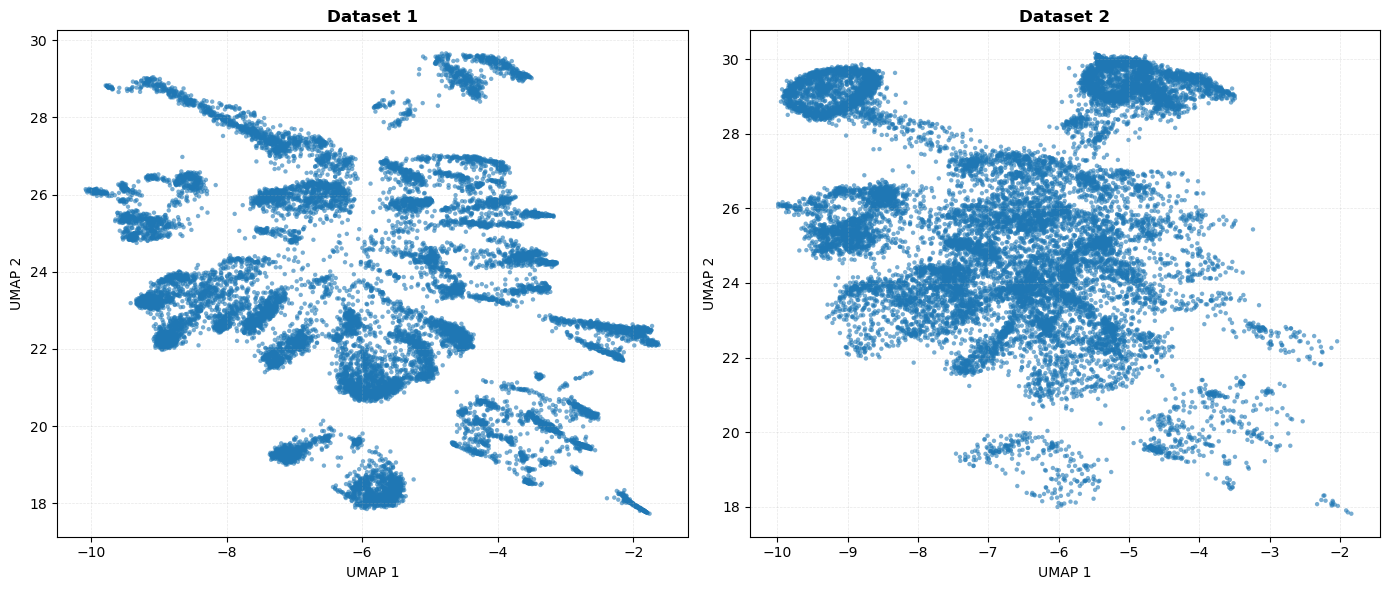

In [17]:
diffusion.eval()
with torch.no_grad():
    full_samples = diffusion.sample(num_samples=len(latent_adata),
                                sampling_timesteps=50,
                                ddim_sampling_eta=0,
                                use_ema=True,
                                clip_denoised=False)
compare_umap(latent_adata.X, full_samples)

Performing UMAP on combined dataset (32764 samples, 128 features)...


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP completed. Generating visualizations...


(array([[-4.83768  , 24.024673 ],
        [-4.6395354, 23.8785   ],
        [-4.7790856, 23.866985 ],
        ...,
        [-6.14858  , 19.448736 ],
        [-5.9399824, 18.669405 ],
        [-6.0470066, 19.655819 ]], shape=(16382, 2), dtype=float32),
 array([[-9.820146 , 28.889662 ],
        [-8.561576 , 22.903795 ],
        [-5.5369043, 23.224022 ],
        ...,
        [-9.579781 , 29.09084  ],
        [-4.9883575, 26.92342  ],
        [-6.59036  , 27.420052 ]], shape=(16382, 2), dtype=float32),
 <Figure size 1400x600 with 2 Axes>)

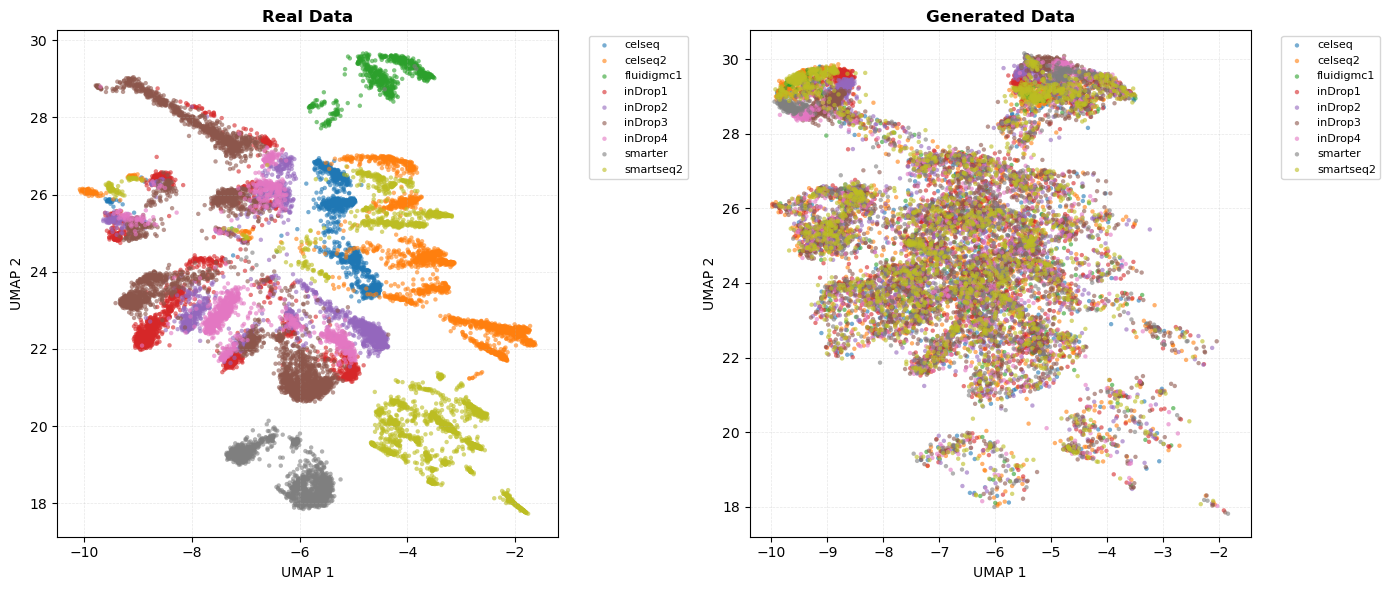

In [18]:
compare_umap(
    latent_adata.X, 
    full_samples.cpu().numpy(),
    labels1=batch_labels,  
    labels2=batch_labels,
    title1="Real Data",
    title2="Generated Data",
    random_state=42
)   

In [9]:

le = LabelEncoder()
batch_tensor = torch.tensor(
    le.fit_transform(batch_labels), dtype=torch.long).to(device)

In [20]:

diffusion.eval()
with torch.no_grad():
    latent_samples = diffusion.sample(
        num_samples=len(batch_tensor),
        sampling_timesteps=50,
        labels=batch_tensor,
        ddim_sampling_eta=0,
        use_ema=True,
        clip_denoised=False,
        guidance_scale=1.0
    )

DDIM sampling: 100%|██████████| 50/50 [01:53<00:00,  2.27s/it]


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


Performing UMAP on combined dataset (32764 samples, 128 features)...
UMAP completed. Generating visualizations...


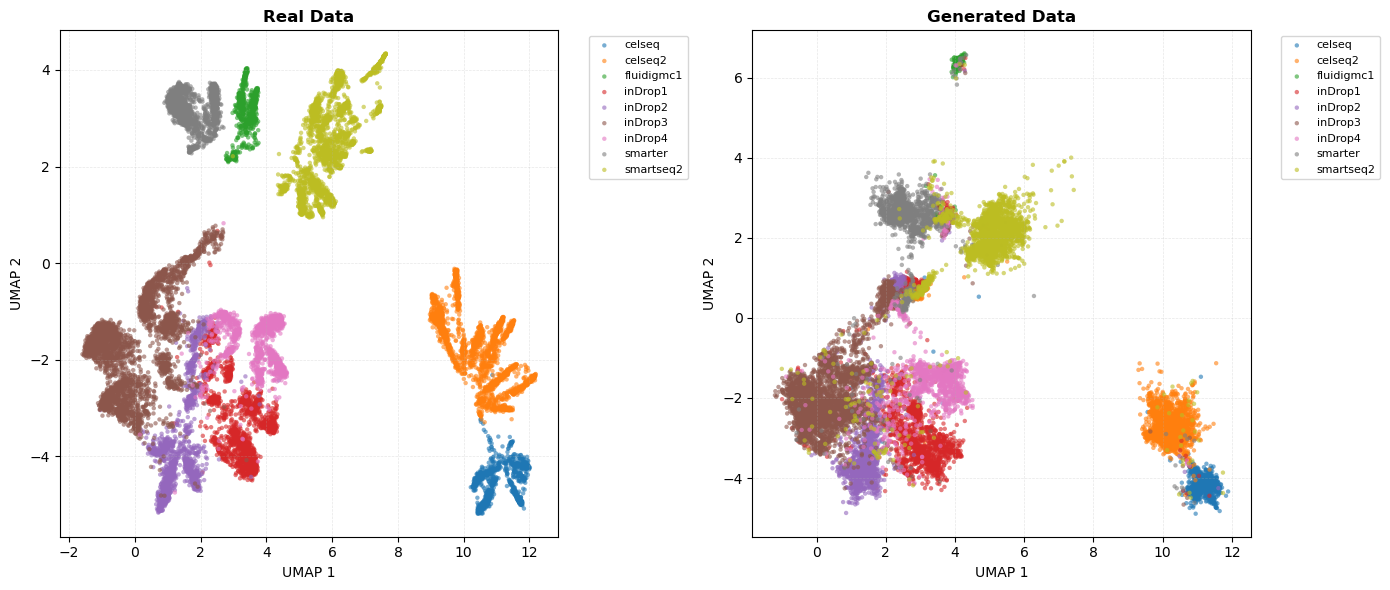

In [21]:
emb1, emb2, fig = compare_umap(
    latent_adata.X, 
    latent_samples.cpu().numpy(),
    labels1=le.inverse_transform(batch_tensor),  
    labels2=le.inverse_transform(batch_tensor),
    title1="Real Data",
    title2="Generated Data",
    random_state=42
)   

In [11]:
# Have to use real data to interpolate. 

celseq1_samples = latent_adata.X[batch_labels == 'celseq']
celseq2_samples = latent_adata.X[batch_labels == 'celseq2']

num_samples = np.min([celseq1_samples.shape[0], celseq2_samples.shape[0]])
celseq1_samples = torch.tensor(celseq1_samples[:num_samples]).to(device)
celseq2_samples = torch.tensor(celseq2_samples[:num_samples]).to(device)   

with torch.no_grad():
    interpolate_05 = diffusion.diffusion.interpolate(x1=celseq1_samples, x2=celseq2_samples, lam=0.5, classes = None, slerp=True)
    interpolate_1 = diffusion.diffusion.interpolate(x1=celseq1_samples, x2=celseq2_samples, lam=1, classes = None, slerp=True)

DDIM interpolation sampling: 100%|██████████| 100/100 [00:06<00:00, 15.86it/s]


In [12]:
interpolate_labels = np.concatenate([np.full(celseq1_samples.shape[0], 'interpolate_05'), np.full(celseq2_samples.shape[0], 'interpolate_1')])  

interpolated_combined_data = np.concatenate([latent_adata.X, interpolate_05, interpolate_1])    
interpolated_combined_labels = np.concatenate([batch_labels, interpolate_labels])   

Performing UMAP on combined dataset (34772 samples, 128 features)...


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP completed. Generating visualizations...


(array([[-6.199548 ,  5.4252095],
        [-6.284178 ,  5.2769694],
        [-6.2480974,  5.30246  ],
        ...,
        [-3.547762 , 17.866371 ],
        [ 5.5273666, 18.493464 ],
        [-3.623472 , 17.754807 ]], shape=(16382, 2), dtype=float32),
 array([[-6.2021966,  5.4040046],
        [-6.293586 ,  5.27036  ],
        [-6.256319 ,  5.303217 ],
        ...,
        [ 8.814027 ,  7.146436 ],
        [-6.2376194, 14.816914 ],
        [-2.8511384, 12.249556 ]], shape=(18390, 2), dtype=float32),
 <Figure size 1400x600 with 2 Axes>)

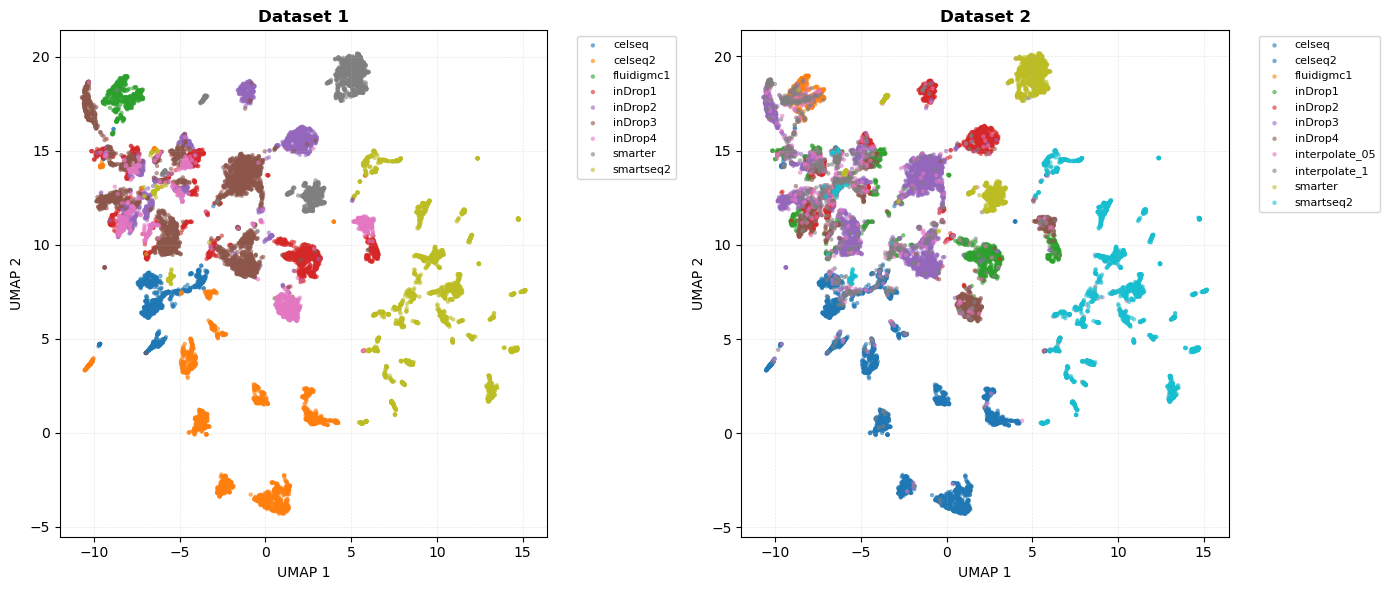

In [13]:
compare_umap(
    latent_adata.X, 
    interpolated_combined_data,
    labels1=batch_labels,
    labels2=interpolated_combined_labels) 

/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


(array([[ 3.7610776,  2.735054 ],
        [ 3.9165344,  2.626384 ],
        [ 3.9143891,  2.6727676],
        ...,
        [-1.4871333,  6.9167438],
        [-7.166035 ,  4.0591784],
        [-2.8247976,  4.12717  ]], shape=(18390, 2), dtype=float32),
 <Figure size 700x600 with 1 Axes>)

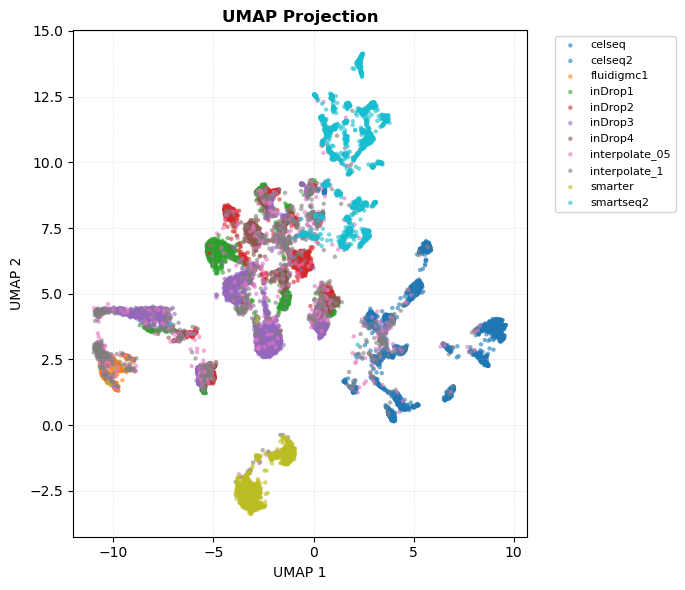

In [14]:
umap_plot(interpolated_combined_data, interpolated_combined_labels)         

/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


(array([[12.189172 ,  9.680479 ],
        [12.344916 ,  9.967322 ],
        [12.402094 ,  9.95366  ],
        ...,
        [-0.5327846,  5.471829 ],
        [ 0.5775071,  3.9791515],
        [ 1.9170238,  3.260378 ]], shape=(2008, 2), dtype=float32),
 <Figure size 700x600 with 1 Axes>)

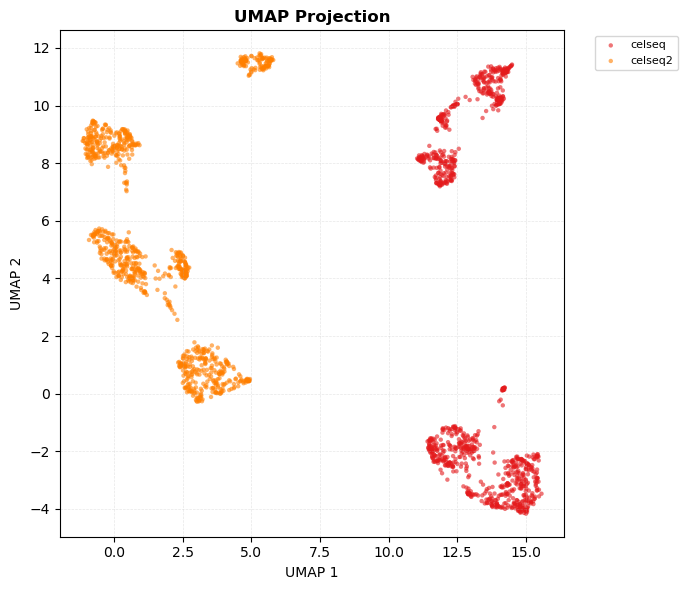

In [17]:
real_celseq_samples  = np.concatenate([celseq1_samples, celseq2_samples])
real_celseq_labels = np.concatenate([np.full(celseq1_samples.shape[0], 'celseq'), np.full(celseq2_samples.shape[0], 'celseq2')])
umap_plot(real_celseq_samples, real_celseq_labels, cmap='Set1')

/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


(array([[55.80671 , 59.80471 ],
        [55.69855 , 60.158813],
        [55.694923, 59.774605],
        ...,
        [56.81796 , 58.42482 ],
        [56.54872 , 56.970734],
        [55.79852 , 59.046135]], shape=(4016, 2), dtype=float32),
 <Figure size 700x600 with 1 Axes>)

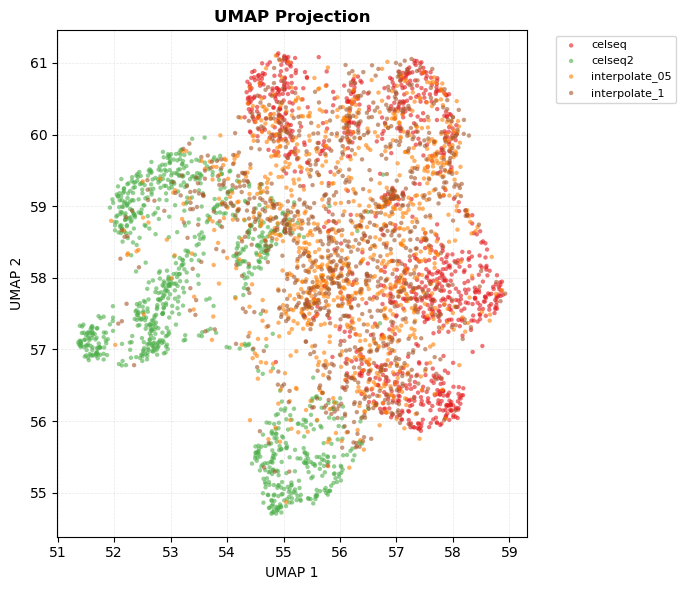

In [16]:
celseq_samples = np.concatenate([celseq1_samples, celseq2_samples, interpolate_05, interpolate_1])
celseq_labels = np.concatenate([np.full(celseq1_samples.shape[0], 'celseq'), np.full(celseq2_samples.shape[0], 'celseq2'), 
                                np.full(interpolate_05.shape[0], 'interpolate_05'), np.full(interpolate_1.shape[0], 'interpolate_1')])
umap_plot(celseq_samples, celseq_labels, cmap='Set1')

Performing UMAP on combined dataset (6024 samples, 128 features)...


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP completed. Generating visualizations...


(array([[ -2.134298 , -25.935738 ],
        [ -2.0694911, -25.677624 ],
        [ -2.1943762, -25.475372 ],
        ...,
        [ -2.3503635, -22.694857 ],
        [ -1.943587 , -19.997028 ],
        [ -2.234947 , -18.730059 ]], shape=(2008, 2), dtype=float32),
 array([[ -2.1308968, -25.970367 ],
        [ -2.074049 , -25.659948 ],
        [ -2.1820304, -25.504671 ],
        ...,
        [ -2.8100014, -26.746029 ],
        [ -3.7059975, -27.294    ],
        [ -2.4290586, -25.35981  ]], shape=(4016, 2), dtype=float32),
 <Figure size 1400x600 with 2 Axes>)

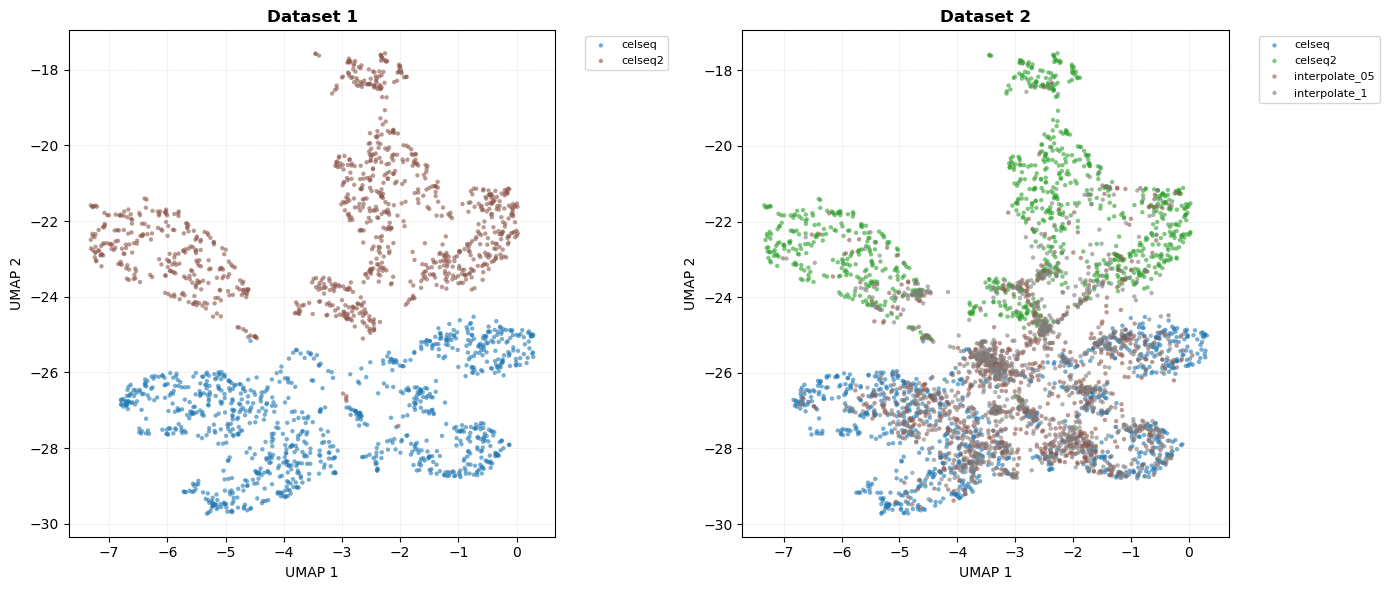

In [18]:
compare_umap(real_celseq_samples, celseq_samples, labels1=real_celseq_labels, labels2=celseq_labels)